In [166]:
include("ALST_BEK.jl")
include("LST_BEK.jl")
using NonlinearEigenproblems
using LinearAlgebra
using ProgressMeter
using FFTW

In [3]:
ω=0
N=99
Ro=1
Co=2
baseflow="Vonkarmen.txt"
θ = range(0,length=N+1,stop=pi)
x = reshape(-cos.(θ), N+1, 1)
c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
X = repeat(x, 1, N+1);
dX = X - X';
D = (c * (1 ./ c)') ./ (dX .+ I(N+1));
D = D - diagm(vec(sum(D, dims=2))); 
for i=1:N+1
    D[i,:]=D[i,:].*((2*x[i]^3-x[i]^2+3*x[i]-4)^2/(20*(6*x[i]^2-2*x[i]+3)))
end
for i=1:N+1
    x[i]=(4*x[i]^3-2*x[i]^2+6*x[i]+12)/(-2*x[i]^3+x[i]^2-3*x[i]+4)
    if x[i]>50
        x[i]=50
    end
end
D2=D^2

100×100 Matrix{Float64}:
      1.32375e6        -2.10339e6    …  1346.06         -672.856
      6.11026e5        -8.7364e5         104.699         -52.3378
 -38151.7               1.46901e5        -27.7301         13.8629
   7526.41         -19747.4               13.4633         -6.73128
  -2378.81           5522.46              -8.45426         4.22741
    974.185         -2140.6          …     6.11896        -3.06005
   -470.556          1003.87              -4.83283         2.41715
    255.112          -534.658              4.03945        -2.02055
   -150.787           312.374             -3.50656         1.75417
     95.3972         -196.049              3.12341        -1.56263
      ⋮                              ⋱                  
      0.000807559      -0.00161342         0.00854144     -0.00426975
     -0.000481977       0.000962966       -0.00502968      0.00251398
      0.000264206      -0.000527881        0.00272587     -0.00136222
     -0.000129073       0.000257892       

In [191]:
#计算部分
# Cr_all=nothing
# R_all=nothing
# @showprogress 1 "Conputing..."     for R=300:1:340
    R=323
    ω=0
    x_0=R
    β=32/R
    A0,A1,A2,A3,A4,dU,dV,dW=KEB_SpatialMode.KEB_LST_ALL(baseflow,N,ω,β,R,Ro,Co,1)
    nep = PEP([A0,A1,A2,A3,A4]); #Create a PEP object
    sc=10
    nep1 = shift_and_scale(nep,scale=sc);
    mult_scale = norm(nep1.A[end]);
    nep2 = PEP(nep1.A ./ mult_scale);
    λ1,v2 = iar(nep2,σ=0.05,neigs=5,maxit=500);
    λ_2 = sc*λ1
    min_imag_abs = Inf
    min_index = 0 
    for i in 1:5
        eigval = λ_2[i]
        if -0.1<imag(eigval) < 0
            curr_imag_abs = abs(imag(eigval))
            if curr_imag_abs < min_imag_abs
                min_imag_abs = curr_imag_abs
                min_index = i
            end
        end
    end  
    if min_index==0
        for i in 1:5
            eigval = λ_2[i]
            if -0.2<imag(eigval)<0.2
                curr_imag_abs = abs(imag(eigval))
                if curr_imag_abs < min_imag_abs
                    min_imag_abs = curr_imag_abs
                    min_index = i
                end
            end
        end
    end
    α_ori=λ_2[min_index,1]
    phi=v2[:,min_index]
    A0_A,A1_A,A2_A,A3_A,A4_A=KEB_ADJ.KEB_ALST(baseflow,N,ω,β,R,Ro,Co)
    # A0_A = transpose(A0);A1_A = transpose(A1);A2_A = transpose(A2);A3_A = transpose(A3);A4_A = transpose(A4)
    nep = PEP([A0_A,A1_A,A2_A,A3_A,A4_A]);
    sc=10
    nep1 = shift_and_scale(nep,scale=sc);
    mult_scale = norm(nep1.A[end]);
    nep2 = PEP(nep1.A ./ mult_scale);
    λ1,v1 = iar(nep2,σ=0.05,neigs=5,maxit=500);
    λ_1 = sc*λ1
    min_imag_abs = Inf
    min_index = 0
    for i in 1:5
        eigval = λ_1[i]
        if -0.1<imag(eigval)<0
            curr_imag_abs = abs(imag(eigval))
            if curr_imag_abs < min_imag_abs
                min_imag_abs = curr_imag_abs
                min_index = i
            end
        end
    end
    if min_index==0
        for i in 1:5
            eigval = λ_1[i]
            if -0.1<imag(eigval)<0.1
                curr_imag_abs = abs(imag(eigval))
                if curr_imag_abs < min_imag_abs
                    min_imag_abs = curr_imag_abs
                    min_index = i
                end
            end
        end
    end
    α_adj=λ_1[min_index,1]
    psi=v1[:,min_index]
    # index2=findmax(abs,psi[1:N+1])
    # psi=psi./psi[index2[2]]
    # index1=findmax(abs,phi[1:N+1])
    # phi=phi./phi[index1[2]]
    A0,A1,A2,A3,A4,dU,dV,dW=KEB_SpatialMode.KEB_LST_ALL(baseflow,N,ω,β,R,Ro,Co,1)
    L=A1 + (α_ori + α_adj) * A2 + (α_ori^2 + α_ori * α_adj + α_adj^2) * A3 + (α_ori^2 + α_adj^2)*(α_ori + α_adj) * A4
    Q=transpose(psi)*(L*phi)


    #
    η_wall=(dU[1]*β-dV[1]*α_ori)*exp(-α_ori*(im*x_0+2*α_ori))
    insert!(psi,1,0)
    insert!(psi,2,0)
    insert!(psi,N,0)
    insert!(psi,N+1,0)
    insert!(psi,N+2,0)
    insert!(psi,2N+2,0)
    insert!(phi,1,0)
    insert!(phi,2,0)
    insert!(phi,N,0)
    insert!(phi,N+1,0)
    insert!(phi,N+2,0)
    insert!(phi,2N+2,0)
    A_0,A_1,A_2,A_3,A_4=KEB_ADJ.KEB_Parameter_Matrix(baseflow,N,ω,α_ori,β,R,Ro,Co,0)
    d2psi=2*(psi[3]-psi[2]+(((x[3]-x[2])/(x[2]-x[1])))*(psi[1]-psi[2]))/((x[3]+x[2]-2*x[1])*(x[3]-x[2]))
    dphi=2*dU[1]*exp(-0.5*α_ori*(2*im*x_0+4*α_ori))
    dpsi_wall=((psi[N+3]-psi[N+2])/(x[2]-x[1]))
    dpsi0=[0 dpsi_wall]
    phi0=[0;η_wall]
    d2psi0=[d2psi 0]
    dphi0=[dphi;0]
    BC_0=dpsi0*A_2*phi0-d2psi0*A_4*dphi0
    Cr=-im*(BC_0/Q)
    Cr=abs.(Cr)
#     Cr_all=[Cr_all;Cr]
#     R_all=[R_all;R]
# end
# R_all=R_all[2:end]
# Cr_all=Cr_all[2:end]
# data=[R_all Cr_all]

1-element Vector{Float64}:
 0.032308260959073534

In [182]:
@show d2psi0

d2psi0 = ComplexF64[330688.1546839193 + 4.875971682192859e6im 0.0 + 0.0im]


1×2 Matrix{ComplexF64}:
 3.30688e5+4.87597e6im  0.0+0.0im

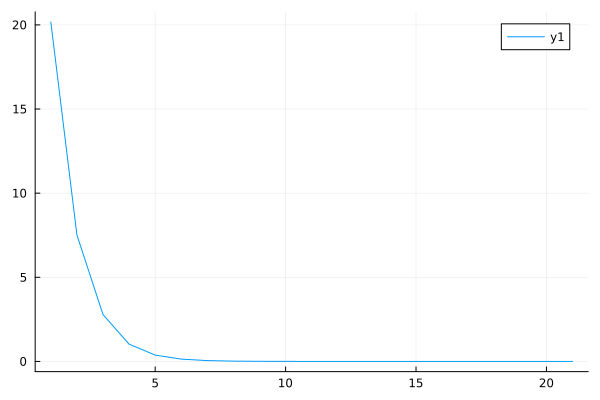

In [110]:
a=nothing
b=nothing
for R=300:5:400
    ω=0
    x_0=R
    β=32/R
    A0,A1,A2,A3,A4,dU,dV,dW=KEB_SpatialMode.KEB_LST_ALL(baseflow,N,ω,β,R,Ro,Co,1)
    nep = PEP([A0,A1,A2,A3,A4]); #Create a PEP object
    sc=10
    nep1 = shift_and_scale(nep,scale=sc);
    mult_scale = norm(nep1.A[end]);
    nep2 = PEP(nep1.A ./ mult_scale);
    λ1,v2 = iar(nep2,σ=0.05,neigs=5,maxit=500);
    λ_2 = sc*λ1
    min_imag_abs = Inf
    min_index = 0 
    for i in 1:5
        eigval = λ_2[i]
        if -0.1<imag(eigval) < 0
            curr_imag_abs = abs(imag(eigval))
            if curr_imag_abs < min_imag_abs
                min_imag_abs = curr_imag_abs
                min_index = i
            end
        end
    end  
    if min_index==0
        for i in 1:5
            eigval = λ_2[i]
            if -0.2<imag(eigval)<0.2
                curr_imag_abs = abs(imag(eigval))
                if curr_imag_abs < min_imag_abs
                    min_imag_abs = curr_imag_abs
                    min_index = i
                end
            end
        end
    end
    α_ori=λ_2[min_index,1]
    phi=v2[:,min_index]
    η_wall=(dU[1]*β-dV[1]*α_ori)*exp(-0.5*α_ori*(2*im*x_0+4*α_ori))
    b=[b;η_wall]

end
b=b[2:end]
using Plots
plot(abs.(b))

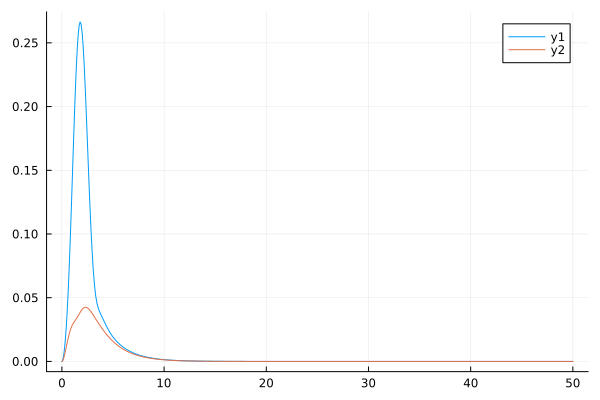

In [106]:
using Plots
plot(x,abs.(psi[1:N+1]))
plot!(x,abs.(phi[1:N+1]))

In [112]:
@show α_ori 

α_ori = 0.5045128167660724 - 0.0001715859842465872im


0.5045128167660724 - 0.0001715859842465872im

In [262]:
transpose(psi)*(A1 + (α_ori + α_adj) * A2 + (α_ori^2 + α_ori * α_adj + α_adj^2) * A3 + (α_ori^2 + α_adj^2)*(α_ori + α_adj)*A4)*phi

-397.7428339158209 + 88.10529025084983im

In [364]:
@show α_1 α

α_1 = 0.5045128167662406 - 0.0001715859850820396im
α = 0.5045128167663666 - 0.0001715859843086833im


0.5045128167663666 - 0.0001715859843086833im

In [201]:
L_m=(A0+A1*α_1+A2*α_1^2+A3*α_1^3+A4*α_1^4)
transpose(v1)*L_m*v2

-2.6237196834699716e-5 - 3.254566149735183e-5im

In [202]:
L_adjoint_n=(A0_A+A1_A*α_1+A2_A*α_1^2+A3_A*α_1^3+A4_A*α_1^4)
transpose(L_adjoint_n*v1)*v2

-9.722109124260664e-13 + 1.587830383479582e-10im

In [196]:
L_adjoint_n

-Inf + Inf*im

In [205]:
L_n = (A0 + A1*α_1 + A2*α_1^2 + A3*α_1^3 + A4*α_1^4)
transpose(v1)*(L_n*v2)

-2.6237195812254296e-5 - 3.2545607061718176e-5im

In [207]:
transpose(v1)*((L_m-L_n)*v2)

0.0 + 0.0im

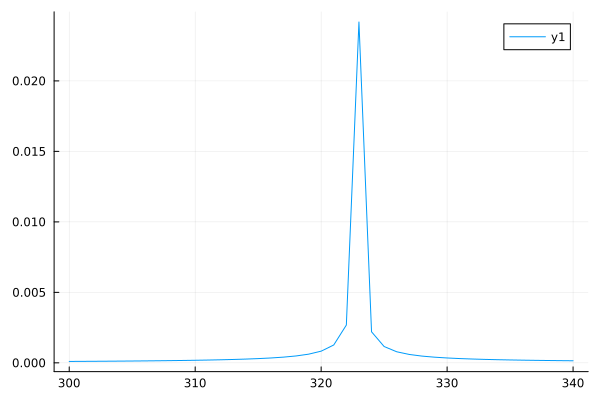

In [421]:
using Plots
plot(R_all,Cr_all)

In [143]:
R=323
ω=0
x_0=R
β=32/R
A0_A,A1_A,A2_A,A3_A,A4_A=KEB_ADJ.KEB_ALST(baseflow,N,ω,β,R,Ro,Co)
nep = PEP([A0_A,A1_A,A2_A,A3_A,A4_A]); #Create a PEP object
sc=10
nep1 = shift_and_scale(nep,scale=sc);
mult_scale = norm(nep1.A[end]);
nep2 = PEP(nep1.A ./ mult_scale);
λ1,v1 = iar(nep2,σ=0.05,neigs=20,maxit=500);
λ_1 = sc*λ1
min_imag_abs = Inf
min_index = 0
for i in 1:20
    eigval = λ_1[i]
    if -0.1<imag(eigval)<0
        curr_imag_abs = abs(imag(eigval))
        if curr_imag_abs < min_imag_abs
            min_imag_abs = curr_imag_abs
            min_index = i
        end
    end
end
if min_index==0
    for i in 1:20
        eigval = λ_1[i]
        if -0.1<imag(eigval)<0.1
            curr_imag_abs = abs(imag(eigval))
            if curr_imag_abs < min_imag_abs
                min_imag_abs = curr_imag_abs
                min_index = i
            end
        end
    end
end
α_adj=λ_1[min_index,1]
v1=v1[:,min_index]
A0,A1,A2,A3,A4,dU,dV=KEB_SpatialMode.KEB_LST_ALL(baseflow,N,ω,β,R,Ro,Co,1)
nep = PEP([A0,A1,A2,A3,A4]); #Create a PEP object
sc=10
nep1 = shift_and_scale(nep,scale=sc);
mult_scale = norm(nep1.A[end]);
nep2 = PEP(nep1.A ./ mult_scale);
λ1,v2 = iar(nep2,σ=0.05,neigs=20,maxit=500);
λ_2 = sc*λ1
min_imag_abs = Inf
min_index = 0 
for i in 1:20
    eigval = λ_2[i]
    if -0.1<imag(eigval) < 0
        curr_imag_abs = abs(imag(eigval))
        if curr_imag_abs < min_imag_abs
            min_imag_abs = curr_imag_abs
            min_index = i
        end
    end
end  
if min_index==0
    for i in 1:20
        eigval = λ_2[i]
        if -0.2<imag(eigval)<0.2
            curr_imag_abs = abs(imag(eigval))
            if curr_imag_abs < min_imag_abs
                min_imag_abs = curr_imag_abs
                min_index = i
            end
        end
    end
end
α_ori=λ_2[min_index,1]
v2=v2[:,min_index]
insert!(v1,1,0)
insert!(v1,2,0)
insert!(v1,N,0)
insert!(v1,N+1,0)
insert!(v1,N+2,0)
insert!(v1,2N+2,0)
insert!(v2,1,0)
insert!(v2,2,0)
insert!(v2,N,0)
insert!(v2,N+1,0)
insert!(v2,N+2,0)
insert!(v2,2N+2,0)
psi=v1
phi=v2
dpsi=[D*psi[1:N+1];D*psi[N+2:2N+2]]
dphi=[D*phi[1:N+1];D*phi[N+2:2N+2]]
f_ori=(im*(dphi)[1:N+1]-(β/α_ori)*phi[N+2:2N+2])/(α_ori+β^2 /α_ori+im/R)
g_ori=(phi[N+2:2N+2]+β*f_ori)/α_ori
h_ori=phi[1:N+1]
f_adj=(im*(dpsi)[1:N+1]-(β/α_adj)*psi[N+2:2N+2])/(α_adj+β^2 /α_adj+im/R)
g_adj=(psi[N+2:2N+2]+β*f_adj)/α_adj
h_adj=psi[1:N+1]
df_adj=D*f_adj
dg_adj=D*g_adj

100-element Vector{ComplexF64}:
      -0.150069908482219 - 0.023731987056884785im
    -0.15011942997305278 - 0.023002638890239225im
     -0.1502603283815158 - 0.02080720960145802im
    -0.15046892806246626 - 0.0171260413736341im
    -0.15070370976651948 - 0.011934985499931664im
     -0.1509030595740731 - 0.0052180201396376715im
      -0.150983766519366 + 0.0030157875546647553im
    -0.15084180161834917 + 0.01271174612799714im
    -0.15035712773608936 + 0.023746662248222833im
     -0.1494042129239129 + 0.03590531582292489im
                         ⋮
  1.6425641562545747e-14 - 1.4288853703006484e-14im
   -7.80406286190191e-15 + 8.85993332631976e-15im
   3.628729162409428e-15 - 4.980317196826974e-15im
 -1.6009615012834067e-15 + 2.4729055493638557e-15im
   6.273573587933894e-16 - 1.0343637704196115e-15im
 -1.9486912900054603e-16 + 3.3218823143884793e-16im
   3.824230952606854e-17 - 6.628068087540983e-17im
 -2.3864152193284988e-18 + 4.166762172453048e-18im
                     0.0 + 0.0im

In [144]:
@show dg_adj[1] df_adj[1]

dg_adj[1] = -0.150069908482219 - 0.023731987056884785im
df_adj[1] = -0.5582431199144916 - 0.451761464720607im


-0.5582431199144916 - 0.451761464720607im

In [ ]:
using Plots
plot(x,abs.(h2),xlims=[0,8])
plot!(x,abs.(f2))
plot!(x,abs.(g2))

In [ ]:
using DelimitedFiles
writedlm("n=40.dat",data ,'\t')